## ECG Processing Pipeline: Steps

### 1. Starting point
* Raw ECG data is loaded from 'data/ECGu.txt' as a NumPy array.

### 2. Analysis Steps
1. **Inspection & Plotting**: Visualize raw signal channels over time to check data quality.
2. **Preprocessing / Filtering**: Remove noise and baseline wander using bandpass filtering.
3. **QRS / R-peak Detection**: Detect R-peaks to identify individual heartbeats.
4. **Heart Rate Calculation**: Compute RR intervals and heart rate in beats per minute (BPM).

### 3. Target Output
* Accurate heart rate metrics (instantaneous BPM, average BPM) and clear visual plots of filtered signals with detected peaks.

In [8]:
# CELLULE 1 : importations
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# CELLULE 2 : charger les donnees dans un tableau NumPy
ecg_raw = np.loadtxt("data/ECGu.txt")

In [10]:
# CELLULE 3 : examinez les donnees (verifiez que les donnees sont correctement chargees)
print(ecg_raw)
print(ecg_raw.shape)

[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]
(6500, 3)


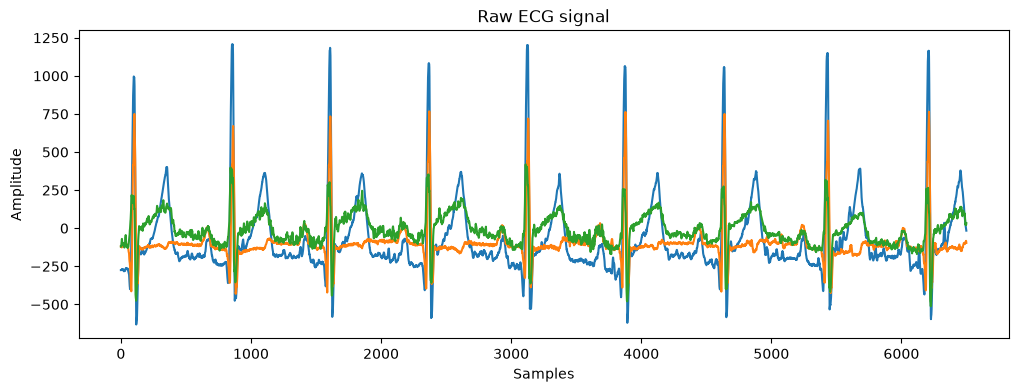

In [11]:
# Plot the three channels of the raw ECG signal
plt.figure(figsize=(12, 4))
plt.plot(ecg_raw)
plt.title("Raw ECG signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

### Visual Inspection of the Plot

The plot matches what is expected for raw ECG data:

1. **What we observe:**
   - There are 3 distinct colored traces, which aligns with the 3 columns in our dataset (shape `(6500, 3)`).
   - Sharp peaks repeat at regular intervals, corresponding to individual heartbeats (R-peaks).

2. **Why the plot is considered correct:**
   - The periodic nature of the peaks confirms this is a genuine biological cardiac signal loaded in the correct temporal order.
   - The signal exhibits high-frequency noise and baseline wander, which is typical for raw physiological data and confirms the need for the subsequent filtering step.

In [12]:
# 5.1 Redimensionner les données aux unités standard
gain_uV = 1024
fs = 1000  # Fréquence d'échantillonnage en Hz

# Conversion en millivolts (mV)
ecg_mv = (ecg_raw * gain_uV) / 1000

# Création de l'axe temporel en secondes
time_s = np.arange(len(ecg_raw)) / fs

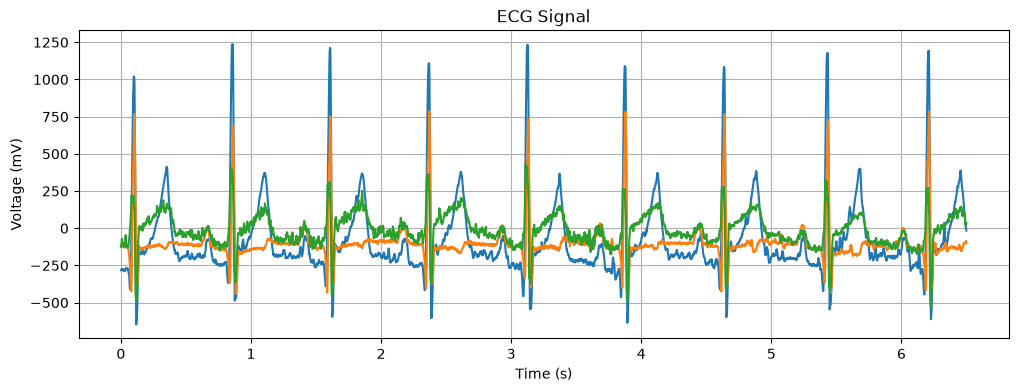

In [13]:
# 5.2 Tracer le signal ECG avec les unités standard (s et mV)
plt.figure(figsize=(12, 4))
plt.plot(time_s, ecg_mv)
plt.title("ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

### Vérification du graphique redimensionné

1. **Le nombre de séries temporelles est-il correct ?**
   - Oui, on voit 3 courbes différentes. Cela correspond bien aux 3 dérivations ECG (I, II et III) indiquées dans la notice du capteur.

2. **Le nombre d'échantillons est-il correct ?**
   - Oui. Le fichier contient 6 500 points mesurés à 1 000 Hz. En divisant 6 500 par 1 000, on obtient 6,5 secondes, ce qui correspond exactement à la graduation de l'axe horizontal.

3. **Les valeurs sont-elles cohérentes avec un signal ECG ?**
   - Oui. Les pics les plus hauts montent entre 1 et 1,25 mV. Chez l'être humain, un battement normal (le complexe QRS) a généralement une amplitude comprise entre 0,5 et 2 mV. Nos valeurs sont donc tout à fait normales.

4. **Questions bonus pour vérifier le graphique :**
   - **Le rythme cardiaque est-il logique ?**
     - On compte environ 7 battements sur les 6,5 secondes d'enregistrement.
     - Calcul : (7 battements / 6,5 secondes) x 60 = environ 65 battements par minute.
     - Pourquoi c'est utile : Un rythme au repos se situe entre 60 et 100 bpm. Cela confirme que l'axe du temps est bien calibré.
   - **La largeur d'un battement est-elle normale ?**
     - Le pic d'un battement dure environ 0,1 seconde (100 millisecondes).
     - Pourquoi c'est utile : Une contraction ventriculaire normale dure moins de 0,12 seconde. Cela prouve que le signal n'a pas été déformé.

In [20]:
print("Temps min/max :", np.min(time_s), np.max(time_s))
print("ECG min/max :", np.min(ecg_mv), np.max(ecg_mv))


Temps min/max : 0.0 6.499
ECG min/max : -647.168 1234.944


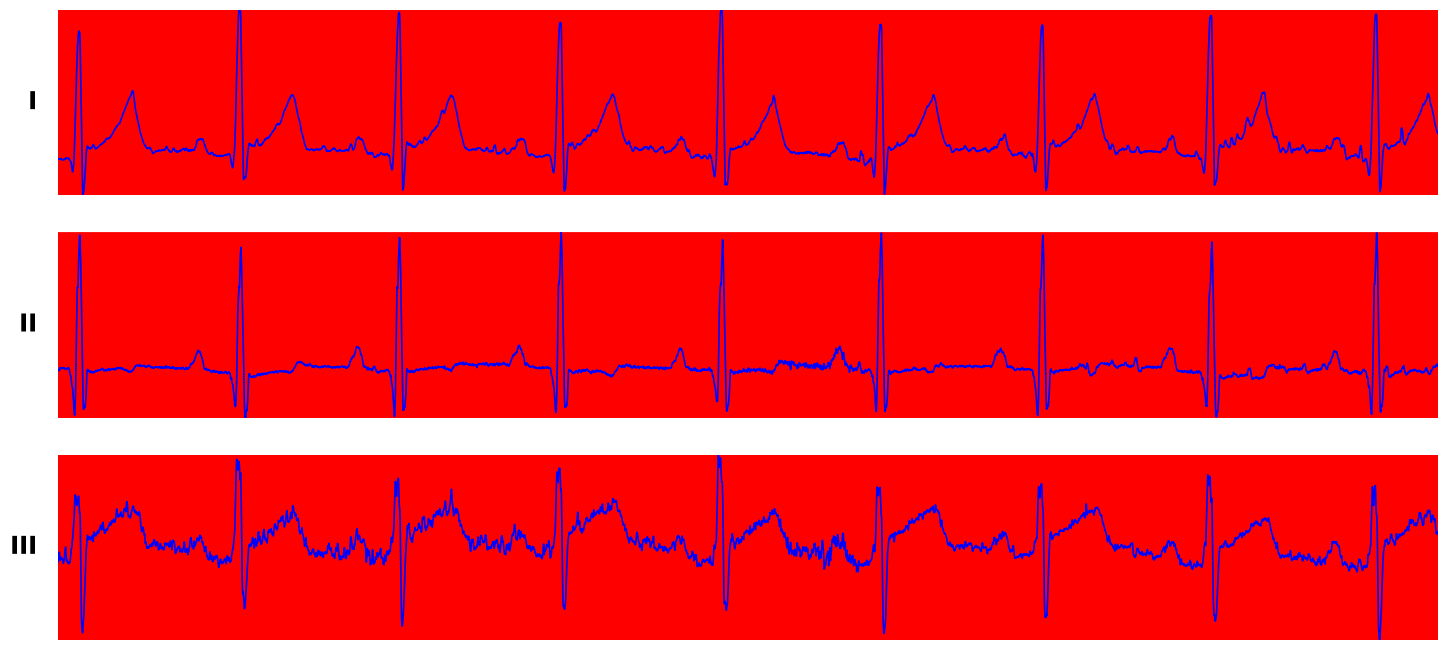

In [21]:
# 7. Créer un graphique qui ressemble à un moniteur ECG réel

def plot_grid(seconds_per_square, mV_per_square, alpha, min_time, max_time, min_ecg, max_ecg):
    """Trace un quadrillage personnalisé sur les axes matplotlib actuels."""
    # Lignes verticales (temps)
    for t in np.arange(min_time, max_time + seconds_per_square, seconds_per_square):
        plt.axvline(x=t, color='red', alpha=alpha, linewidth=0.6)
    # Lignes horizontales (tension)
    for v in np.arange(min_ecg, max_ecg + mV_per_square, mV_per_square):
        plt.axhline(y=v, color='red', alpha=alpha, linewidth=0.6)

def plot_ecg_grid(min_time, max_time, min_ecg, max_ecg):
    """Trace la grille ECG standard (grandes cases 0.2s/0.5mV et petites 0.04s/0.1mV)."""
    # Lignes plus claires à 1/5 des intervalles (0.04 s et 0.1 mV)
    plot_grid(seconds_per_square=0.04, mV_per_square=0.1, alpha=0.15,
              min_time=min_time, max_time=max_time, min_ecg=min_ecg, max_ecg=max_ecg)
    # Lignes principales (0.2 s et 0.5 mV)
    plot_grid(seconds_per_square=0.2, mV_per_square=0.5, alpha=0.4,
              min_time=min_time, max_time=max_time, min_ecg=min_ecg, max_ecg=max_ecg)

def plot_one_ecg_signal(temps, ecg, lead_name, couleur):
    """Trace le signal ECG d'une dérivation sur les axes actuels."""
    plt.plot(temps, ecg, color=couleur, linewidth=1.2)

def plot_one_lead_in_subplots(subplot, temps, ecg, lead_name, couleur, total_subplots=3):
    """Trace une dérivation sur la grille d'un sous-graphique."""
    ax = plt.subplot(total_subplots, 1, subplot)
    
    # Bornes calées sur la grille ECG standard
    min_time = float(temps[0])
    max_time = float(temps[-1])
    min_ecg = np.floor(np.min(ecg) / 0.5) * 0.5 - 0.5
    max_ecg = np.ceil(np.max(ecg) / 0.5) * 0.5 + 0.5
    
    # Tracé de la grille et du signal
    plot_ecg_grid(min_time, max_time, min_ecg, max_ecg)
    plot_one_ecg_signal(temps, ecg, lead_name, couleur)
    
    # Limites d'affichage
    plt.xlim(min_time, max_time)
    plt.ylim(min_ecg, max_ecg)
    
    # Nom de la dérivation à gauche (I, II, III)
    ax.text(-0.015, 0.5, lead_name, transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='center', ha='right')
    
    # Style moniteur médical (retrait du cadre noir et des chiffres d'axes)
    ax.axis('off')

def plot_all_leads_in_subplots(temps, ecg, lead_names, couleurs):
    """Trace toutes les dérivations ECG dans des sous-graphiques superposés."""
    total_leads = ecg.shape[1]
    plt.figure(figsize=(15, 7))
    for i in range(total_leads):
        plot_one_lead_in_subplots(
            subplot=i + 1,
            temps=temps,
            ecg=ecg[:, i],
            lead_name=lead_names[i],
            couleur=couleurs[i],
            total_subplots=total_leads
        )
    plt.subplots_adjust(hspace=0.2, left=0.06, right=0.98, top=0.95, bottom=0.05)
    plt.show()

# Exécution avec les paramètres demandés
lead_names = ["I", "II", "III"]
couleurs = ["blue", "blue", "blue"]

plot_all_leads_in_subplots(time_s, ecg_mv, lead_names, couleurs)


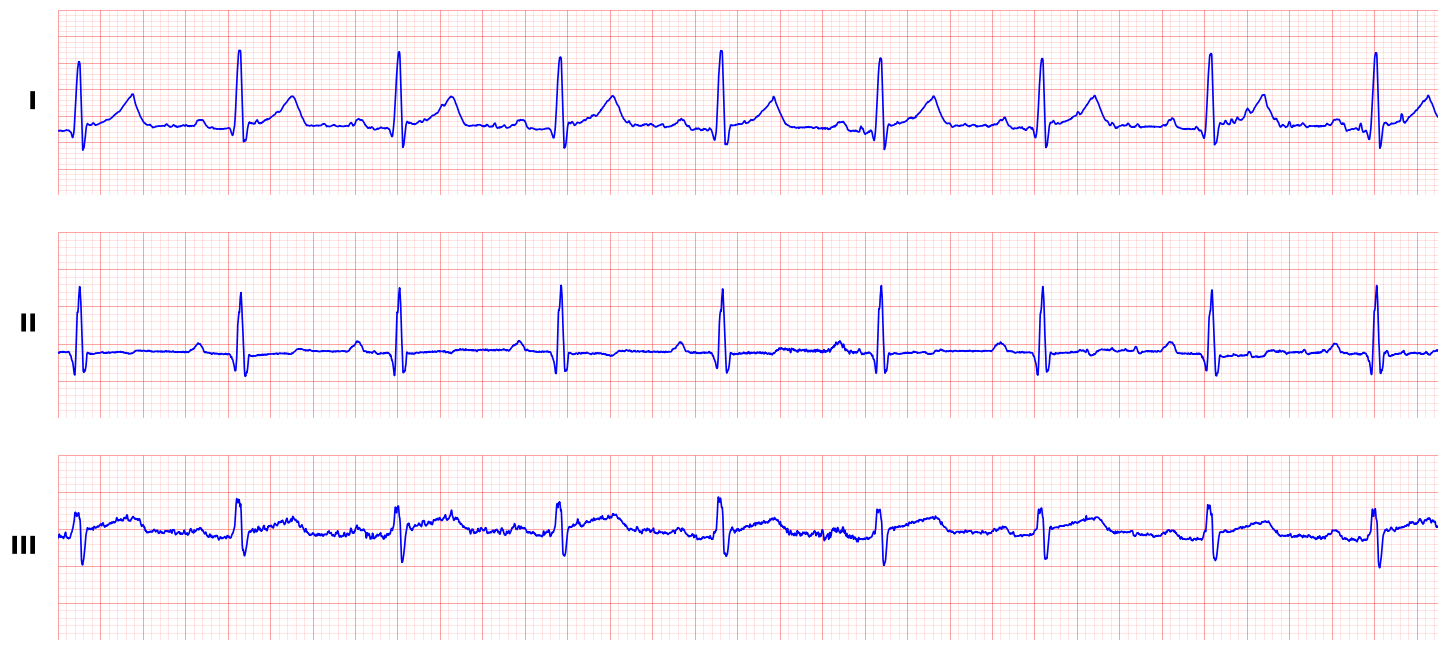

In [22]:
# 7. Créer un graphique qui ressemble à un moniteur ECG réel

def plot_grid(seconds_per_square, mV_per_square, alpha, min_time, max_time, min_ecg, max_ecg):
    """Trace la grille avec les espacements spécifiés."""
    t_vals = np.arange(min_time, max_time + seconds_per_square * 0.5, seconds_per_square)
    v_vals = np.arange(min_ecg, max_ecg + mV_per_square * 0.5, mV_per_square)
    
    # Tracé des lignes délimitées
    plt.vlines(t_vals, min_ecg, max_ecg, colors='red', alpha=alpha, linewidths=0.5)
    plt.hlines(v_vals, min_time, max_time, colors='red', alpha=alpha, linewidths=0.5)

def plot_ecg_grid(min_time, max_time, min_ecg, max_ecg):
    """Trace la grille ECG standard (0.2s/0.5mV et subdivision au 1/5)."""
    # 3. Lignes fines (0.04 s et 0.1 mV)
    plot_grid(seconds_per_square=0.04, mV_per_square=0.1, alpha=0.15,
              min_time=min_time, max_time=max_time, min_ecg=min_ecg, max_ecg=max_ecg)
    # 1 & 2. Lignes majeures (0.2 s et 0.5 mV)
    plot_grid(seconds_per_square=0.2, mV_per_square=0.5, alpha=0.4,
              min_time=min_time, max_time=max_time, min_ecg=min_ecg, max_ecg=max_ecg)

def plot_one_ecg_signal(temps, ecg, lead_name, couleur):
    """Trace le signal ECG d'une dérivation."""
    plt.plot(temps, ecg, color=couleur, linewidth=1.2)

def plot_one_lead_in_subplots(subplot, temps, ecg, lead_name, couleur):
    """Trace une dérivation et sa grille sur un sous-graphique."""
    ax = plt.subplot(3, 1, subplot)
    
    # Ajuste en mV si les données brutes sont en microvolts
    signal_mv = ecg / 1000.0 if np.max(np.abs(ecg)) > 50 else ecg
    
    min_time = float(temps[0])
    max_time = float(temps[-1])
    min_ecg = np.floor(np.min(signal_mv) / 0.5) * 0.5 - 0.5
    max_ecg = np.ceil(np.max(signal_mv) / 0.5) * 0.5 + 0.5
    
    # Tracé de la grille et de la courbe
    plot_ecg_grid(min_time, max_time, min_ecg, max_ecg)
    plot_one_ecg_signal(temps, signal_mv, lead_name, couleur)
    
    # Cadrage
    plt.xlim(min_time, max_time)
    plt.ylim(min_ecg, max_ecg)
    
    # Nom de dérivation à gauche (I, II, III)
    ax.text(-0.015, 0.5, lead_name, transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='center', ha='right')
    
    # Retrait du cadre noir extérieur
    ax.axis('off')

def plot_all_leads_in_subplots(temps, ecg, lead_names, couleurs):
    """Trace l'ensemble des dérivations superposées."""
    plt.figure(figsize=(15, 7))
    for i in range(ecg.shape[1]):
        plot_one_lead_in_subplots(
            subplot=i + 1,
            temps=temps,
            ecg=ecg[:, i],
            lead_name=lead_names[i],
            couleur=couleurs[i]
        )
    plt.subplots_adjust(hspace=0.2, left=0.06, right=0.98, top=0.95, bottom=0.05)
    plt.show()

# Exécution avec les paramètres demandés
lead_names = ["I", "II", "III"]
couleurs = ["blue", "blue", "blue"]

plot_all_leads_in_subplots(time_s, ecg_mv, lead_names, couleurs)